In [17]:
import numpy as np

def simple_pagerank(links, damping_factor=0.85, max_iterations=100, tolerance=1e-6):
    """
    简易PageRank算法实现
    
    参数:
    links: 邻接矩阵或链接关系字典
    damping_factor: 阻尼因子，通常设为0.85
    max_iterations: 最大迭代次数
    tolerance: 收敛阈值
    
    返回:
    每个节点的PageRank值
    """
    
    # 处理不同的输入格式
    if isinstance(links, dict):
        # 从字典格式构建邻接矩阵
        nodes = list(links.keys())
        n = len(nodes)
        node_to_idx = {node: i for i, node in enumerate(nodes)}
        
        # 构建邻接矩阵
        # M 是 列随机矩阵，每列和为1
        #M[i][j] = 从页面j跳转到页面i的概率
        M = np.zeros((n, n))
        for from_node, to_nodes in links.items():
            from_idx = node_to_idx[from_node]
            out_degree = len(to_nodes)
            if out_degree > 0:
                for to_node in to_nodes:
                    to_idx = node_to_idx[to_node]
                    M[to_idx, from_idx] = 1 / out_degree
    else:
        # 已经是矩阵格式
        M = np.array(links)
        n = M.shape[0]
        nodes = list(range(n))
    
    # 处理悬挂节点（没有出链的节点）
    # 将全零列替换为均匀分布
    # 将悬挂节点（没有出链的页面）的转移概率设置为均匀分布，
    # 确保该页面的权重能够正确传递给整个网络，保证PageRank算法的数学收敛性和实际合理性。
    dangling_nodes = np.where(M.sum(axis=0) == 0)[0]
    for node in dangling_nodes:
        M[:, node] = 1 / n
    
    # 初始化PageRank向量
    pr = np.ones(n) / n
    
    # PageRank迭代计算
    for iteration in range(max_iterations):
        # 计算新的PageRank值
        # M @ pr  # 矩阵乘法：转移概率 × 当前PageRank
        # (1 - damping_factor) / n  # 每个页面获得的均匀随机跳转权重
        new_pr = damping_factor * M @ pr + (1 - damping_factor) / n
        
        # 检查收敛
        diff = np.abs(new_pr - pr).sum()
        if diff < tolerance:
            print(f"在第 {iteration + 1} 次迭代后收敛")
            break
        
        pr = new_pr
    
    return dict(zip(nodes, pr))

def normalize_pagerank(pagerank_scores):
    """归一化PageRank分数到0-100范围"""
    total = sum(pagerank_scores.values())
    return {node: (score / total) * 100 for node, score in pagerank_scores.items()}

In [18]:
import matplotlib.pyplot as plt

def visualize_pagerank(pagerank_scores, title="PageRank"):
    """可视化PageRank结果"""
    nodes = list(pagerank_scores.keys())
    scores = list(pagerank_scores.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(nodes, scores, color='skyblue', alpha=0.7)
    
    # 添加数值标签
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{score:.3f}', ha='center', va='bottom')
    
    plt.title(title)
    plt.xlabel('nodes')
    plt.ylabel('PageRank value')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# 示例1：简单的网页链接关系
web_links = {
    'A': ['B', 'C'],  # 页面A链接到B和C
    'B': ['C'],       # 页面B链接到C
    'C': ['A'],       # 页面C链接到A
    'D': ['A', 'C']   # 页面D链接到A和C
}

print("=== 示例1：网页链接网络 ===")
pagerank_scores = simple_pagerank(web_links)
normalized_scores = normalize_pagerank(pagerank_scores)

print("PageRank分数:")
for page, score in pagerank_scores.items():
    print(f"页面 {page}: {score:.4f}")

print("\n归一化分数 (0-100):")
for page, score in normalized_scores.items():
    print(f"页面 {page}: {score:.2f}")

=== 示例1：网页链接网络 ===
在第 28 次迭代后收敛
PageRank分数:
页面 A: 0.3797
页面 B: 0.1989
页面 C: 0.3839
页面 D: 0.0375

归一化分数 (0-100):
页面 A: 37.97
页面 B: 19.89
页面 C: 38.39
页面 D: 3.75


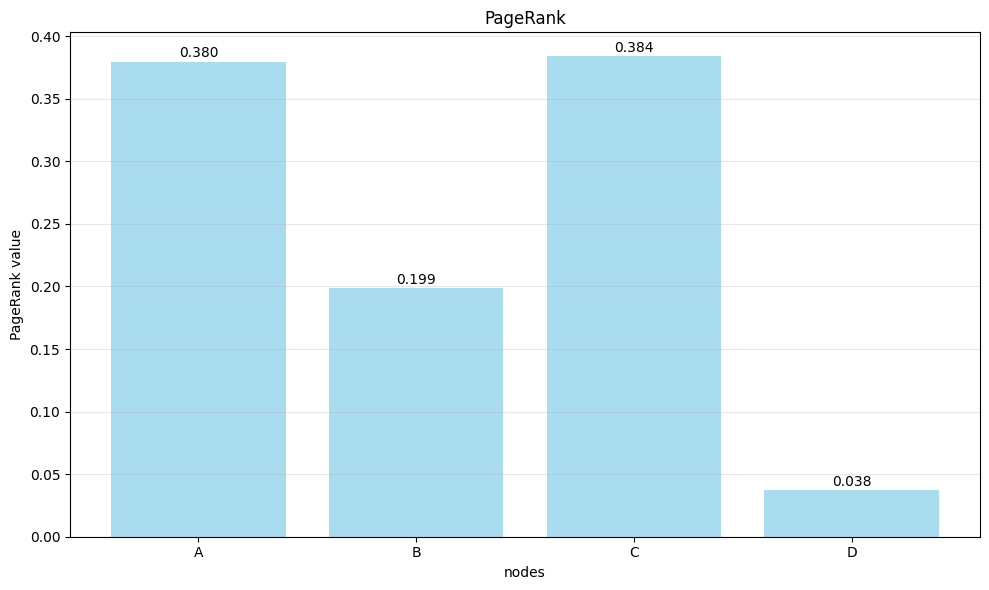

In [16]:
# 可视化第一个示例的结果
visualize_pagerank(pagerank_scores, "PageRank")

In [3]:
# 示例2：社交网络关注关系
social_network = {
    'Alice': ['Bob', 'Charlie', 'David'],
    'Bob': ['Alice', 'Charlie'],
    'Charlie': ['David'],
    'David': ['Alice', 'Bob', 'Charlie'],
    'Eve': ['Alice', 'David']  # 新用户，关注了Alice和David
}

print("\n=== 示例2：社交网络 ===")
social_pagerank = simple_pagerank(social_network, damping_factor=0.85)
social_normalized = normalize_pagerank(social_pagerank)

print("用户影响力排名:")
sorted_users = sorted(social_normalized.items(), key=lambda x: x[1], reverse=True)
for user, score in sorted_users:
    print(f"{user}: {score:.2f}")


=== 示例2：社交网络 ===
在第 14 次迭代后收敛
用户影响力排名:
David: 32.13
Charlie: 25.75
Alice: 21.06
Bob: 18.07
Eve: 3.00
